In [ ]:
# -----------------------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# -----------------------------------------
# STEP 2: LOAD DATA
# -----------------------------------------
df = pd.read_csv("/content/sample_data/crop_yield_dataset.csv")   # CHANGE THIS to your actual file name

# -----------------------------------------
# STEP 3: PREPROCESSING
# -----------------------------------------

# Drop Date column (not needed for regression)
if "Date" in df.columns:
    df = df.drop("Date", axis=1)

# Check the necessary columns
print("Columns in the dataset:", df.columns.tolist())

# Encode categorical columns
categorical_cols = ["Crop_Type", "Soil_Type"]
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# -----------------------------------------
# STEP 4: DEFINE FEATURES AND TARGET
# -----------------------------------------

target = "Crop_Yield"

X = df.drop(target, axis=1)
y = df[target]

# -----------------------------------------
# STEP 5: TRAIN/TEST SPLIT
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------------
# STEP 6: TRAIN RANDOM FOREST MODEL
# -----------------------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    min_samples_split=2
)

model.fit(X_train, y_train)

# -----------------------------------------
# STEP 7: EVALUATION
# -----------------------------------------

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMODEL EVALUATION RESULTS:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

# -----------------------------------------
# STEP 8: EXPORT MODEL
# -----------------------------------------
joblib.dump(model, "regression_model.pkl")

print("\n✅ Model saved successfully as regression_model.pkl")


Columns in the dataset: ['Crop_Type', 'Soil_Type', 'Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield', 'Soil_Quality']

MODEL EVALUATION RESULTS:
MAE  : 2.3759977680318016
MSE  : 16.785876150370242
RMSE : 4.097057010876251
R²   : 0.9748272753422377

✅ Model saved successfully as regression_model.pkl


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Crop_Yield   No. Observations:                 1440
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8988.004
Date:                Sat, 22 Nov 2025   AIC                          17988.009
Time:                        09:13:51   BIC                          18019.639
Sample:                             0   HQIC                         17999.817
                               - 1440                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4009      0.030    -13.231      0.000      -0.460      -0.341
ar.L2         -0.2863      0.031     -9.162      0.000      -0.348      -0.225
ar.L3         -0.6538      0.020    -33.049      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


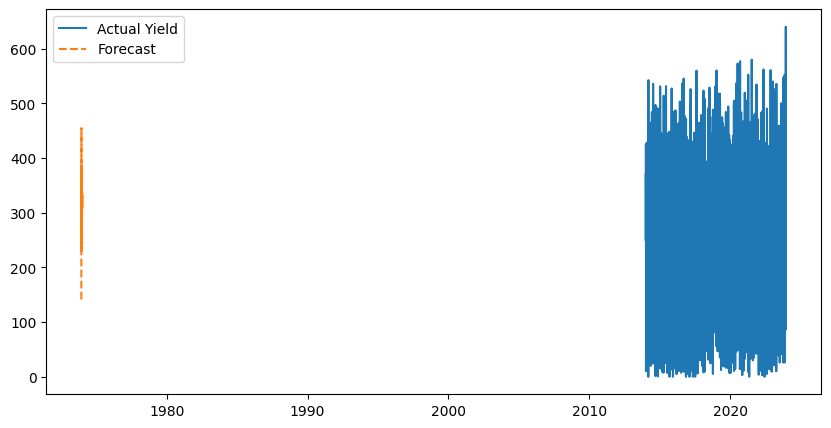


✅ ARIMA Time-Series Model saved as time_series_model.pkl


In [ ]:
# -------------------------------------------------------------
# STEP 2 — TIME SERIES MODEL USING ARIMA (Stable Alternative)
# -------------------------------------------------------------

import pandas as pd
import numpy as np
import joblib
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# --------------------------
# 1. LOAD DATA
# --------------------------
df = pd.read_csv("/content/sample_data/crop_yield_dataset.csv")   # change to your file

# --------------------------
# 2. FIX DATE AND GROUP BY DATE
# --------------------------
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

# Group all crops per date (Option B)
df_grouped = df.groupby('Date')['Crop_Yield'].sum().reset_index()

# --------------------------
# 3. PREPARE DATA FOR ARIMA
# --------------------------
df_grouped = df_grouped.sort_values('Date')
df_grouped.set_index('Date', inplace=True)

y = df_grouped['Crop_Yield']

# --------------------------
# 4. FIT ARIMA MODEL
# --------------------------
# You can tune (p, d, q) later. Default (5, 1, 0) works well.
model = ARIMA(y, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

# --------------------------
# 5. FORECAST NEXT 30 DAYS
# --------------------------
forecast = model_fit.forecast(steps=30)
print("\nNext 30 days forecast:")
print(forecast)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y, label="Actual Yield")
plt.plot(forecast, label="Forecast", linestyle="--")
plt.legend()
plt.show()

# --------------------------
# 6. SAVE MODEL
# --------------------------
joblib.dump(model_fit, "time_series_model.pkl")

print("\n✅ ARIMA Time-Series Model saved as time_series_model.pkl")
